In [1]:
!pip install scAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of louvain to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 35.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 30.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 72.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 73.1 MB/s eta 0:00:00
  Created wheel for louv

In [2]:
import numpy as np

from scAnalysis import (
    sc_io,
    preprocessing,
    quality_control,
    cell_cycle,
    batch_correction,
    dimensionality,
    clustering,
    trajectory,
    differential,
    enrichment,
    visualization,
    interactive_viz,
    imputation,
)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

In [4]:
local_h5ad_path = "/content/drive/MyDrive/resources/grn_benchmark/inference_data/nakatake_rna.h5ad"
data = sc_io.read_h5ad(local_h5ad_path)

IO: Reading H5AD from '/content/drive/MyDrive/resources/grn_benchmark/inference_data/nakatake_rna.h5ad' ...
IO: Loaded 460 cells × 25,090 genes.


In [5]:
print(data)
print(data.obs.columns.tolist())

SingleCellDataset object with n_obs × n_vars = 460 × 25090
    obs: perturbation, is_control, perturbation_type, n_genes
    var: n_cells
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id
    Memory (X): 88.05 MB
['perturbation', 'is_control', 'perturbation_type', 'n_genes']


In [6]:
data.var.index = sc_io._make_unique(data.var.index.values)

In [7]:
preprocessing.calculate_qc_metrics(data, qc_vars=["MT-", "mt-"])

In [8]:
quality_control.scrublet(data, verbose=True)
mask_singlets = ~data.obs['predicted_doublet'].astype(bool)
data = data[mask_singlets, :]

Scrublet: Starting doublet detection...
Scrublet: Filtering genes...
Scrublet: Kept 25090/25090 genes
Scrublet: Selected 3764 variable genes
Scrublet: Simulating 920 doublets...
Scrublet: Normalizing data...
Scrublet: Computing 30 PCs...
Scrublet: Calculating doublet scores...
Scrublet: Detected 25 doublets (5.4%)
Scrublet: Threshold = 0.833


In [9]:
data = preprocessing.filter_cells(data, min_genes=200, max_pct_mito=15.0)
data = preprocessing.filter_genes(data, min_cells=3)

filter_cells: keeping 435 / 435 cells.
filter_genes: keeping 25,090 / 25,090 genes.


In [10]:
preprocessing.normalize_total(data, target_sum=1e4)
preprocessing.log1p(data)

In [11]:
preprocessing.highly_variable_genes(data, n_top_genes=2000)

HVG: identified 2,000 highly variable genes.


In [12]:
data.raw = data.copy()

In [13]:
preprocessing.scale(data, max_value=10)

In [14]:
dimensionality.run_pca(data, n_components=50)

PCA: using 2,000 HVGs.
PCA: computed 50 components (78.0% variance explained).


SingleCellDataset object with n_obs × n_vars = 435 × 25090
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, doublet_score, predicted_doublet
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, pca
    obsm: X_pca
    varm: PCs
    Memory (X): 83.27 MB

In [ ]:
# NOTE: Harmony batch correction was removed here because there is no
# 'donor_id' or 'batch' column in the nakatake_rna dataset.

In [15]:
dimensionality.neighbors(data, n_neighbors=15, n_pcs=40)
dimensionality.run_umap(data, min_dist=0.3)

Neighbors: k=15, metric='euclidean' …
Neighbors: graph built (435 cells).
UMAP: min_dist=0.3, n_components=2 …


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


SingleCellDataset object with n_obs × n_vars = 435 × 25090
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, doublet_score, predicted_doublet
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, pca, neighbors
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 83.27 MB

In [16]:
clustering.cluster_leiden(data, resolution=0.5, key_added="leiden")

Clustering: Leiden resolution=0.5 …
Leiden: found 3 clusters.


SingleCellDataset object with n_obs × n_vars = 435 × 25090
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, doublet_score, predicted_doublet, leiden
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, pca, neighbors
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 83.27 MB

In [17]:
differential.rank_genes_groups(data, groupby='leiden', method='wilcoxon', use_raw=True)

Differential: Ranking genes for 3 groups using wilcoxon (use_raw=True) …
  … processing group '0'
  … processing group '1'
  … processing group '2'


SingleCellDataset object with n_obs × n_vars = 435 × 25090
    obs: perturbation, is_control, perturbation_type, n_genes, n_genes_by_counts, total_counts, pct_counts_MT-, pct_counts_mt-, doublet_score, predicted_doublet, leiden
    var: n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: encoding-type, encoding-version, data_reference, data_url, dataset_description, dataset_id, dataset_name, dataset_organism, dataset_summary, normalization_id, pca, neighbors, rank_genes_groups
    obsm: X_pca, X_umap
    varm: PCs
    Memory (X): 83.27 MB

In [18]:
first_cluster = sorted(data.obs['leiden'].unique())[0]

In [23]:
cluster_markers = differential.get_marker_genes(
    data,
    group=first_cluster,
    pval_cutoff=1.0,
    lfc_cutoff=0.0
)
print(f"Top 5 markers for cluster '{first_cluster}':{cluster_markers.head(5)}")

Top 5 markers for cluster '0':     names     scores  logfoldchanges         pvals     pvals_adj  pct_in  \
0    TERF1  15.373712        0.117281  2.456788e-53  4.315439e-49     1.0   
1     PLP1  14.917854        0.165903  2.522547e-50  2.109690e-46     1.0   
2  TERF1P4  14.789279        0.113967  1.717836e-49  1.077513e-45     1.0   
3     HES3  14.754213        0.198984  2.890427e-49  1.450416e-45     1.0   
4  TERF1P2  14.714472        0.132923  5.205113e-49  2.176605e-45     1.0   

   pct_out  
0      1.0  
1      1.0  
2      1.0  
3      1.0  
4      1.0  


In [24]:
visualization.plot_umap(data, color="perturbation", title="UMAP - Perturbations", legend_loc="right margin", save="nakatake_umap_perturbation.png")

Saved → nakatake_umap_perturbation.png


<Axes: title={'center': 'UMAP - Perturbations'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [25]:
visualization.plot_umap(data, color="is_control", title="UMAP - Control Status", save="nakatake_umap_control.png")

Saved → nakatake_umap_control.png


<Axes: title={'center': 'UMAP - Control Status'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [26]:
visualization.plot_umap(data, color="leiden", title="UMAP - Leiden Clusters", legend_loc="on data", save="nakatake_umap_leiden.png")

Saved → nakatake_umap_leiden.png


<Axes: title={'center': 'UMAP - Leiden Clusters'}, xlabel='X_umap 1', ylabel='X_umap 2'>

Saved → nakatake_volcano_leiden.png


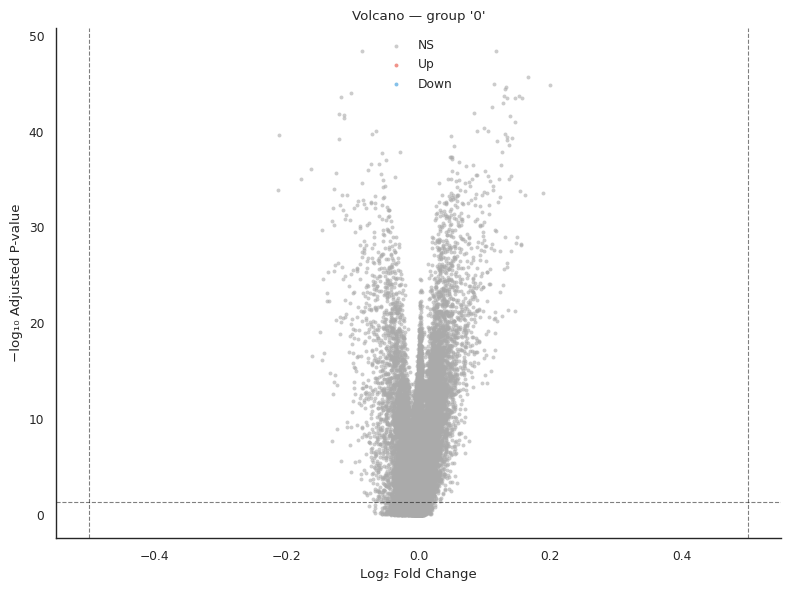

In [27]:
visualization.volcano_plot(data, group=first_cluster, top_n_genes=5, save="nakatake_volcano_leiden.png")

In [28]:
try:
    interactive_viz.interactive_embedding(
        data,
        basis='X_umap',
        color='leiden',
        hover_data=['perturbation', 'is_control'],
        title="Interactive UMAP (Nakatake Dataset)",
        save_html="nakatake_interactive_umap.html"
    )

    interactive_viz.interactive_3d_embedding(
        data,
        basis='X_pca',
        color='leiden',
        dimensions=[0, 1, 2],
        save_html="nakatake_interactive_3d_pca.html"
    )

    if 'cluster_markers' in locals() and not cluster_markers.empty:
        top_genes = cluster_markers['names'].head(10).tolist()
        valid_genes = [g for g in top_genes if g in data.var.index]

        if valid_genes:
            interactive_viz.interactive_heatmap(
                data,
                var_names=valid_genes,
                groupby='leiden',
                use_raw=True,
                save_html="nakatake_interactive_heatmap.html"
            )
except Exception as e:
    print(f"Skipped interactive plot: {e}")


Interactive plot saved to nakatake_interactive_umap.html
3D plot saved to nakatake_interactive_3d_pca.html
Interactive heatmap saved to nakatake_interactive_heatmap.html


In [29]:
output_file = "nakatake_rna_processed.h5ad"
sc_io.write_h5ad(data, output_file)

IO: Writing H5AD -> 'nakatake_rna_processed.h5ad' ...
IO: Wrote 435 cells × 25,090 genes.
